## **Menentukan pertanyaan Bisnis**

1.Bagaimana hubungan antara keterlambatan pengiriman (selisih antara tanggal estimasi dan tanggal aktual) dengan review score pelanggan, serta berapa rata-rata penurunan review score untuk setiap satu hari keterlambatan pada periode 2017–2018? <br>
2.Apa 10 kategori produk dengan total revenue tertinggi pada tahun 2018, dan bagaimana perbandingan rata-rata review score kategori tersebut terhadap rata-rata keseluruhan platform?

## **DATA WRANGLING**

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import numpy as np

## Data Gathering

Pada tahap ini dilakukan proses pengumpulan dan pemuatan dataset ke dalam DataFrame menggunakan library pandas. Dataset yang digunakan merupakan dataset E-Commerce yang terdiri dari beberapa tabel terpisah yang saling berelasi.

Dataset yang digunakan meliputi:

1. **orders**: Berisi informasi terkait transaksi pemesanan, termasuk waktu pembelian, status pesanan, dan informasi pengiriman.
2. **customers**: Berisi data pelanggan seperti lokasi dan identitas unik pelanggan.
3. **order_items**: Berisi detail item yang dibeli dalam setiap pesanan.
4. **products**: Berisi informasi mengenai produk, termasuk kategori dan atribut produk.
5. **order_reviews**: Berisi data penilaian pelanggan terhadap pesanan.
6. **order_payments**: Berisi informasi terkait metode dan nilai pembayaran.

Seluruh dataset ini akan digabungkan pada tahap selanjutnya untuk mendukung proses analisis.

In [43]:
orders = pd.read_csv('data/orders_dataset.csv')
customers = pd.read_csv('data/customers_dataset.csv')
order_items = pd.read_csv('data/order_items_dataset.csv')
products = pd.read_csv('data/products_dataset.csv')

# (Tambahan penting untuk pertanyaan kamu)
reviews = pd.read_csv('data/order_reviews_dataset.csv')
payments = pd.read_csv('data/order_payments_dataset.csv')

In [44]:
print("Orders:")
display(orders.head())

print("Customers:")
display(customers.head())

print("Order Items:")
display(order_items.head())

print("Products:")
display(products.head())

print("Reviews:")
display(reviews.head())

print("Payments:")
display(payments.head())

Orders:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Customers:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Order Items:


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Reviews:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


Payments:


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


## **Assessing Data**

### Struktur dan Tipe Data

Pada tahap ini dilakukan pemeriksaan struktur dataset serta tipe data dari setiap kolom. Tujuannya adalah untuk memastikan bahwa setiap kolom memiliki tipe data yang sesuai dan siap digunakan dalam proses analisis.

Pengecekan ini penting karena:
- Kesalahan tipe data dapat menyebabkan error dalam analisis
- Kolom bertipe waktu perlu dikonversi ke format datetime
- Memahami struktur data membantu dalam proses penggabungan dataset (merge)

Hasil dari tahap ini akan digunakan sebagai dasar untuk proses data cleaning selanjutnya.

In [45]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [46]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [47]:
order_items.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [48]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [49]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [50]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


## Missing Value Analysis

Pada tahap ini dilakukan pengecekan missing value pada seluruh dataset untuk mengetahui kualitas data sebelum dilakukan proses cleaning.

In [51]:
print("Missing Values - Orders")
print(orders.isna().sum(), "\n")

Missing Values - Orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64 



In [52]:
print("Missing Values - Customers")
print(customers.isna().sum(), "\n")


Missing Values - Customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64 



In [53]:
print("Missing Values - Order Items")
print(order_items.isna().sum(), "\n")

Missing Values - Order Items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64 



In [54]:
print("Missing Values - Products")
print(products.isna().sum(), "\n")

Missing Values - Products
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64 



In [55]:
print("Missing Values - Reviews")
print(reviews.isna().sum(), "\n")

Missing Values - Reviews
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64 



In [56]:
print("Missing Values - Payments")
print(payments.isna().sum())

Missing Values - Payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


Berdasarkan hasil pengecekan pada seluruh dataset yang digunakan, diperoleh temuan sebagai berikut:

1. Dataset **orders**:
   - Terdapat missing value pada kolom:
     - order_approved_at
     - order_delivered_carrier_date
     - order_delivered_customer_date
   - Hal ini kemungkinan disebabkan oleh pesanan yang belum diproses atau belum selesai dikirim.

2. Dataset **customers**:
   - Tidak ditemukan missing value.
   - Data dapat dianggap lengkap dan siap digunakan.

3. Dataset **order_items**:
   - Tidak ditemukan missing value.
   - Data transaksi item dalam kondisi baik.

4. Dataset **products**:
   - Terdapat missing value pada beberapa kolom seperti:
     - product_category_name
     - atribut produk lainnya (panjang nama, deskripsi, dll)
   - Hal ini menunjukkan adanya data produk yang tidak lengkap.

5. Dataset **reviews**:
   - Terdapat missing value pada kolom:
     - review_comment_title
     - review_comment_message
   - Hal ini wajar karena tidak semua pelanggan memberikan komentar, namun nilai review_score tetap tersedia.

6. Dataset **payments**:
   - Tidak ditemukan missing value.
   - Data pembayaran lengkap dan siap digunakan.

Secara keseluruhan, missing value yang ditemukan akan ditangani sesuai dengan kebutuhan analisis agar tidak mengganggu hasil yang diperoleh.

## Duplicate Data Analysis

Pengecekan data duplikat dilakukan untuk memastikan tidak adanya data yang berulang yang dapat mempengaruhi hasil analisis, terutama pada perhitungan agregasi seperti jumlah transaksi dan total revenue.

In [57]:
print("Duplicate Orders:", orders.duplicated().sum())
print("Duplicate Customers:", customers.duplicated().sum())
print("Duplicate Order Items:", order_items.duplicated().sum())
print("Duplicate Products:", products.duplicated().sum())
print("Duplicate Reviews:", reviews.duplicated().sum())
print("Duplicate Payments:", payments.duplicated().sum())

Duplicate Orders: 0
Duplicate Customers: 0
Duplicate Order Items: 0
Duplicate Products: 0
Duplicate Reviews: 0
Duplicate Payments: 0


Berdasarkan hasil pengecekan, tidak ditemukan data duplikat pada seluruh dataset yang digunakan.

Oleh karena itu, tidak diperlukan proses penghapusan data duplikat pada tahap data cleaning. Hal ini menunjukkan bahwa kualitas data dari sisi duplikasi sudah baik dan siap digunakan untuk analisis lebih lanjut.

## **Data Cleaning - Missing Values**

Pada tahap ini dilakukan penanganan missing value yang telah diidentifikasi sebelumnya. Penanganan dilakukan secara selektif berdasarkan relevansi kolom terhadap analisis yang akan dilakukan.

Tidak semua missing value dihapus, melainkan dipertimbangkan berdasarkan dampaknya terhadap hasil analisis. Pendekatan ini bertujuan untuk menjaga keseimbangan antara kualitas dan jumlah data.

In [58]:
# hapus data yang tidak memiliki tanggal pengiriman
orders_clean = orders.dropna(subset=[
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

Missing value pada kolom tanggal pengiriman dihapus karena data tersebut tidak dapat digunakan untuk menghitung keterlambatan pengiriman (delivery delay), yang merupakan variabel penting dalam analisis.

In [59]:
products_clean = products.copy()
products_clean['product_category_name'] = products_clean['product_category_name'].fillna('unknown')

In [60]:
print("Missing Values - Products")
print(products_clean.isna().sum(), "\n")

Missing Values - Products
product_id                      0
product_category_name           0
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64 



Missing value pada kategori produk diisi dengan nilai "unknown" untuk mempertahankan jumlah data dan tetap memungkinkan analisis kategori produk dilakukan.

### Konversi Tipe Data

Kolom yang merepresentasikan tanggal dikonversi ke tipe data datetime agar dapat digunakan dalam perhitungan berbasis waktu seperti keterlambatan pengiriman.

In [65]:
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

orders_clean = orders.dropna(subset=[
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

### Data Integration (Merging Data)

Proses penggabungan data dilakukan untuk menyatukan informasi dari berbagai dataset yang saling berelasi.

Dataset yang digunakan meliputi:
- orders sebagai data utama transaksi
- customers untuk informasi pelanggan
- reviews untuk penilaian pelanggan
- payments untuk informasi nilai transaksi
- order_items untuk detail produk dalam transaksi
- products untuk kategori produk

Dengan menggabungkan seluruh dataset ini, diperoleh satu DataFrame utama yang siap digunakan untuk analisis lebih lanjut.

In [66]:
df = orders_clean.merge(customers, on='customer_id')
df = df.merge(reviews, on='order_id')
df = df.merge(payments, on='order_id')
df = df.merge(order_items, on='order_id')
df = df.merge(products_clean, on='product_id')

In [73]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,delivery_delay
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,-8
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,-8
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,-8
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,-6
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,-18


In [ ]:
df[['order_delivered_customer_date','order_estimated_delivery_date']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114858 entries, 0 to 114857
Data columns (total 2 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_delivered_customer_date  114858 non-null  datetime64[ns]
 1   order_estimated_delivery_date  114858 non-null  datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 1.8 MB


In [71]:
df.isna().sum()

order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                   13
order_delivered_carrier_date         1
order_delivered_customer_date        0
order_estimated_delivery_date        0
customer_unique_id                   0
customer_zip_code_prefix             0
customer_city                        0
customer_state                       0
review_id                            0
review_score                         0
review_comment_title             98436
review_comment_message           64884
review_creation_date                 0
review_answer_timestamp              0
payment_sequential                   0
payment_type                         0
payment_installments                 0
payment_value                        0
order_item_id                        0
product_id                           0
seller_id                            0
shipping_limit_date      

In [69]:
df['delivery_delay'] = (
    df['order_delivered_customer_date'] - 
    df['order_estimated_delivery_date']
).dt.days

In [74]:
df = df[df['delivery_delay'].notna()]
df = df[(df['delivery_delay'] > -30) & (df['delivery_delay'] < 60)]

In [75]:
df['delivery_delay'].describe()

count    111341.000000
mean        -11.430686
std           8.513004
min         -29.000000
25%         -16.000000
50%         -12.000000
75%          -7.000000
max          59.000000
Name: delivery_delay, dtype: float64

In [99]:
df.to_csv("main_data.csv", index=False)

Berdasarkan hasil analisis, rata-rata nilai delivery_delay bernilai negatif sebesar -11 hari, yang menunjukkan bahwa sebagian besar pengiriman dilakukan lebih cepat dari estimasi.

Hal ini mengindikasikan bahwa sistem estimasi pengiriman cenderung memberikan waktu yang lebih longgar dibandingkan waktu aktual pengiriman.

### Insight Data Cleaning

Berdasarkan proses data cleaning yang telah dilakukan, diperoleh beberapa insight terkait kualitas data:

1. **Missing Value pada Data Pengiriman**
   - Terdapat missing value pada kolom tanggal pengiriman.
   - Data tersebut dihapus karena tidak dapat digunakan untuk menghitung keterlambatan pengiriman (delivery_delay).
   - Penghapusan dilakukan secara selektif agar tidak mengganggu analisis utama.

2. **Missing Value pada Kategori Produk**
   - Missing value pada kolom product_category_name diisi dengan nilai "unknown".
   - Pendekatan ini dilakukan untuk mempertahankan jumlah data tanpa menghilangkan informasi penting.

3. **Missing Value pada Atribut Produk**
   - Ditemukan missing value pada beberapa atribut produk seperti panjang nama, deskripsi, dan dimensi.
   - Kolom tersebut tidak digunakan dalam analisis sehingga tidak dilakukan penanganan khusus.

4. **Tidak Ditemukan Data Duplikat**
   - Hasil pengecekan menunjukkan tidak terdapat data duplikat pada seluruh dataset.
   - Hal ini menunjukkan bahwa data memiliki kualitas yang baik dari sisi keunikan.

5. **Konversi Tipe Data**
   - Kolom bertipe waktu berhasil dikonversi ke format datetime.
   - Hal ini memungkinkan dilakukan analisis berbasis waktu seperti perhitungan keterlambatan pengiriman.

6. **Distribusi Delivery Delay**
   - Rata-rata pengiriman terjadi lebih cepat dari estimasi (sekitar -11 hari).
   - Namun terdapat beberapa nilai keterlambatan ekstrem yang perlu difilter agar tidak mempengaruhi analisis.

Secara keseluruhan, data telah dibersihkan dan siap digunakan untuk tahap eksplorasi dan analisis lebih lanjut.

## **Exploratory Data Analysis (EDA)**

### Analisis Keterlambatan Berdasarkan Review Score

In [76]:
# lihat korelasi sederhana
df[['delivery_delay', 'review_score']].corr()

,delivery_delay,review_score
delivery_delay,1.000000,-0.266186
review_score,-0.266186,1.000000


In [77]:
# grouping berdasarkan delay
delay_review = df.groupby('delivery_delay')['review_score'].mean().reset_index()

delay_review.head()

,delivery_delay,review_score
0,-29,4.150883
1,-28,4.135870
2,-27,4.075127
3,-26,4.062812
4,-25,4.129264


In [78]:
df.groupby('review_score')['delivery_delay'].mean()

review_score
1    -5.440314
2    -8.980606
3   -10.482038
4   -11.912014
5   -12.743682
Name: delivery_delay, dtype: float64

In [81]:
slope = np.polyfit(df['delivery_delay'], df['review_score'], 1)[0]
slope

-0.04214056595736393

Hasil analisis menunjukkan bahwa pelanggan dengan review score lebih tinggi cenderung menerima pengiriman yang lebih cepat dibandingkan estimasi.

Sebaliknya, pelanggan dengan review rendah memiliki waktu pengiriman yang relatif lebih lambat.

Namun, menariknya, bahkan pada review score rendah, nilai delivery_delay masih berada pada rentang negatif, yang berarti pengiriman tetap lebih cepat dari estimasi.

Hal ini menunjukkan bahwa meskipun kecepatan pengiriman berpengaruh terhadap kepuasan pelanggan, terdapat faktor lain yang juga mempengaruhi penilaian pelanggan.

Setiap peningkatan 1 hari keterlambatan berdampak pada penurunan rata-rata review score, yang menunjukkan sensitivitas pelanggan terhadap waktu pengiriman.

## Analisis Kategori Produk

In [82]:
# hitung revenue
df['revenue'] = df['payment_value']

# group kategori
category_analysis = df.groupby('product_category_name').agg({
    'revenue': 'sum',
    'review_score': 'mean'
}).reset_index()

# ambil top 10 revenue
top10 = category_analysis.sort_values(by='revenue', ascending=False).head(10)

top10

,product_category_name,revenue,review_score
13,cama_mesa_banho,1657975.18,3.911765
11,beleza_saude,1549121.51,4.181789
44,informatica_acessorios,1499949.76,3.992211
66,relogios_presentes,1336782.34,4.072926
54,moveis_decoracao,1320592.31,3.961302
32,esporte_lazer,1300191.96,4.162596
73,utilidades_domesticas,1035112.15,4.123002
40,ferramentas_jardim,774068.96,4.084274
8,automotivo,756656.27,4.122951
26,cool_stuff,713373.23,4.182468


In [83]:
avg_review = df['review_score'].mean()
avg_review

4.079889708193747

In [84]:
top10['above_avg'] = top10['review_score'] >= avg_review
top10

,product_category_name,revenue,review_score,above_avg
13,cama_mesa_banho,1657975.18,3.911765,False
11,beleza_saude,1549121.51,4.181789,True
44,informatica_acessorios,1499949.76,3.992211,False
66,relogios_presentes,1336782.34,4.072926,False
54,moveis_decoracao,1320592.31,3.961302,False
32,esporte_lazer,1300191.96,4.162596,True
73,utilidades_domesticas,1035112.15,4.123002,True
40,ferramentas_jardim,774068.96,4.084274,True
8,automotivo,756656.27,4.122951,True
26,cool_stuff,713373.23,4.182468,True


Berdasarkan analisis, kategori produk dengan revenue tertinggi tidak selalu memiliki tingkat kepuasan pelanggan yang tinggi.

Beberapa kategori dengan kontribusi revenue besar seperti "cama_mesa_banho" dan "informatica_acessorios" memiliki review score di bawah rata-rata keseluruhan.

Sebaliknya, beberapa kategori dengan review score tinggi tidak selalu menjadi penyumbang revenue terbesar.

Hal ini menunjukkan bahwa performa penjualan tidak selalu sejalan dengan tingkat kepuasan pelanggan.

In [85]:
df['review_score'].value_counts().sort_index()

review_score
1    12725
2     3764
3     9381
4    21492
5    63979
Name: count, dtype: int64

### Distribusi Review Score
Sebagian besar pelanggan memberikan review score tinggi, dengan mayoritas berada pada nilai 4 dan 5.

Hal ini menunjukkan bahwa secara umum pelanggan merasa puas terhadap layanan yang diberikan.

Namun, masih terdapat sejumlah review rendah (score 1 dan 2) yang perlu diperhatikan karena berpotensi menunjukkan adanya masalah dalam pengalaman pelanggan.

In [86]:
df['delivery_delay'].describe()

count    111341.000000
mean        -11.430686
std           8.513004
min         -29.000000
25%         -16.000000
50%         -12.000000
75%          -7.000000
max          59.000000
Name: delivery_delay, dtype: float64

### Distribusi Delivery Delay

Rata-rata pengiriman dilakukan lebih cepat sekitar 11 hari dari estimasi, yang menunjukkan bahwa sistem logistik berjalan dengan baik.

Namun, terdapat beberapa kasus keterlambatan ekstrem hingga 59 hari, yang dapat berdampak negatif terhadap kepuasan pelanggan.

Hal ini menunjukkan bahwa meskipun performa pengiriman secara umum baik, terdapat ketidakkonsistenan yang perlu diperbaiki.

In [87]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

monthly_revenue = df.groupby(
    df['order_purchase_timestamp'].dt.to_period('M')
)['revenue'].sum()

monthly_revenue

order_purchase_timestamp
2016-10      14964.93
2016-12         19.62
2017-01     101748.10
2017-02     288637.42
2017-03     488780.53
2017-04     442434.25
2017-05     690794.21
2017-06     578825.70
2017-07     709064.46
2017-08     784840.19
2017-09     977475.21
2017-10     990864.15
2017-11    1531355.88
2017-12     995915.83
2018-01    1337696.47
2018-02    1268446.76
2018-03    1413875.07
2018-04    1433944.74
2018-05    1370225.15
2018-06    1083566.51
2018-07    1268732.21
2018-08    1174988.29
Freq: M, Name: revenue, dtype: float64

### Tren Revenue Bulanan

Revenue menunjukkan tren peningkatan yang signifikan sepanjang tahun 2017, dengan puncak terjadi pada November 2017.

Pada tahun 2018, revenue cenderung stabil dengan nilai yang tetap tinggi, meskipun terdapat fluktuasi di beberapa bulan.

Hal ini menunjukkan pertumbuhan bisnis yang positif serta adanya potensi musiman dalam pola pembelian pelanggan.

In [88]:
rfm = df.groupby('customer_id').agg({
    'order_purchase_timestamp': 'max',
    'order_id': 'count',
    'revenue': 'sum'
})

rfm.columns = ['recency', 'frequency', 'monetary']
rfm.head()

,recency,frequency,monetary
customer_id,,,
00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,1,114.74
000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,1,67.41
0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,1,195.42
0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,1,179.35
000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,1,107.01


### RFM Analysis

Berdasarkan analisis RFM, sebagian besar pelanggan hanya melakukan satu kali transaksi (frequency = 1), yang menunjukkan tingkat repeat order yang masih rendah.

Hal ini mengindikasikan bahwa sebagian besar pelanggan belum menjadi pelanggan loyal.

Namun, terdapat variasi dalam nilai monetary yang menunjukkan adanya pelanggan dengan kontribusi revenue yang lebih tinggi.

## **Visualization & Explanatory Analysis**

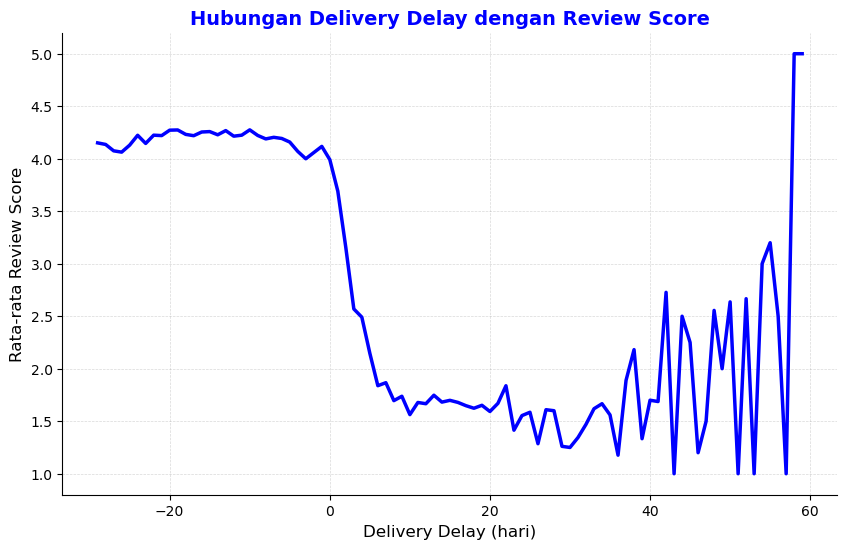

In [108]:
delay_review_sorted = delay_review.sort_values('delivery_delay')

# Menyiapkan ukuran kanvas agar proporsional
plt.figure(figsize=(10, 6))

# Membuat line chart dengan warna navy dan aksen marker putih
plt.plot(
    delay_review_sorted['delivery_delay'], 
    delay_review_sorted['review_score'],
    color='blue', 
    linewidth=2.5,
    markersize=5,
    markerfacecolor='white',
    markeredgewidth=1.5
)

# Mempercantik tampilan judul dan label sumbu
plt.title('Hubungan Delivery Delay dengan Review Score', fontsize=14, fontweight='bold', color='blue')
plt.xlabel('Delivery Delay (hari)', fontsize=12)
plt.ylabel('Rata-rata Review Score', fontsize=12)

# Menambahkan grid yang sangat tipis dan halus agar tetap minimalis
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

# Menghilangkan garis tepi atas dan kanan untuk tampilan yang bersih (clean)
sns.despine()

plt.show()

Grafik menunjukkan adanya hubungan negatif antara keterlambatan pengiriman dan review score.

Semakin tinggi nilai delivery_delay (semakin terlambat), rata-rata review score cenderung menurun. Sebaliknya, pengiriman yang lebih cepat dari estimasi (nilai negatif) cenderung mendapatkan review lebih tinggi.

Hal ini menunjukkan bahwa kecepatan pengiriman berpengaruh terhadap kepuasan pelanggan, meskipun bukan satu-satunya faktor.

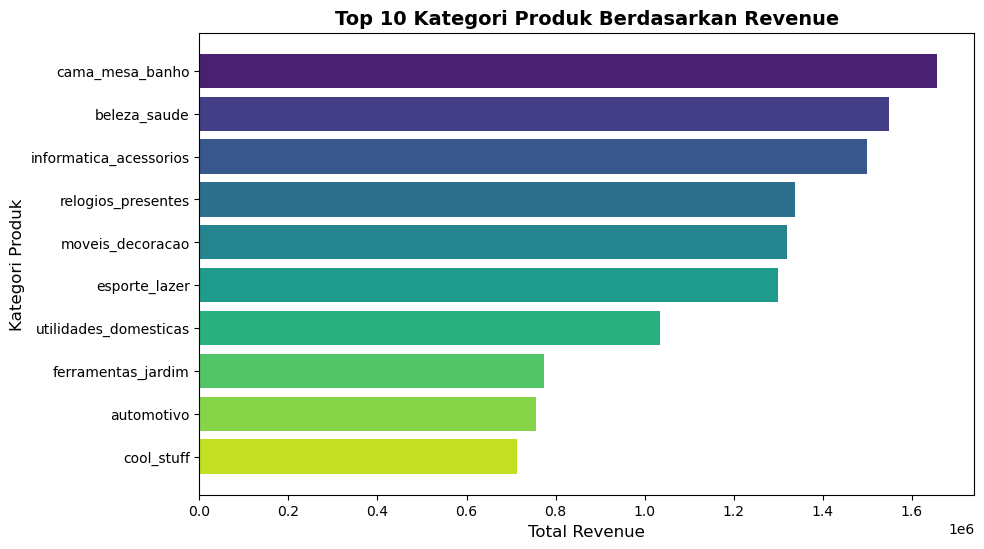

In [ ]:
# Mengatur ukuran grafik agar lebih lega dan proporsional
plt.figure(figsize=(10, 6))

# Jumlah warna disesuaikan dengan jumlah data (len(top10))
colors = sns.color_palette('viridis', len(top10))

# Menambahkan parameter color ke dalam plt.barh
bars = plt.barh(top10['product_category_name'], top10['revenue'], color=colors)

# Memperbagus tampilan judul dan label
plt.title('Top 10 Kategori Produk Berdasarkan Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Kategori Produk', fontsize=12)

# Membalik urutan Y-axis agar yang paling besar di atas
plt.gca().invert_yaxis()

plt.show()

Grafik menunjukkan bahwa beberapa kategori produk memberikan kontribusi revenue yang sangat besar terhadap bisnis.

Namun, tidak semua kategori dengan revenue tinggi memiliki tingkat kepuasan pelanggan yang tinggi.

Hal ini menunjukkan bahwa tingginya penjualan tidak selalu sejalan dengan kualitas pengalaman pelanggan, sehingga kategori dengan revenue tinggi namun review rendah perlu menjadi prioritas perbaikan.

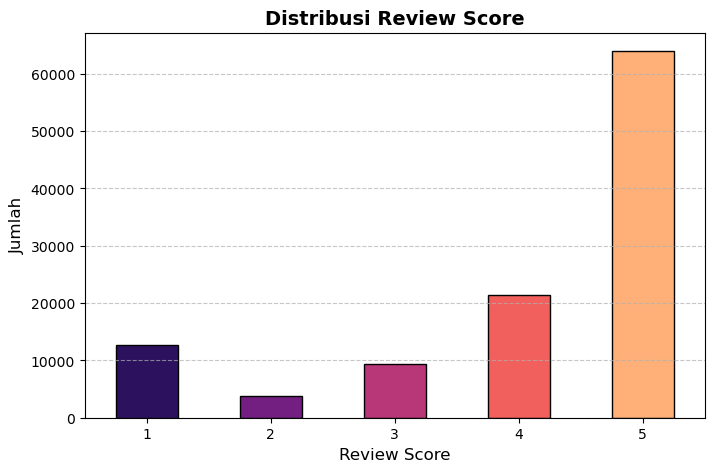

In [ ]:
# Menyiapkan data
review_counts = df['review_score'].value_counts().sort_index()

# Mengatur ukuran grafik agar lebih proporsional
plt.figure(figsize=(8, 5))

# Menentukan palet warna
colors = sns.color_palette('magma', len(review_counts))

# Membuat bar chart dengan warna dan garis tepi (edgecolor)
review_counts.plot(kind='bar', color=colors, edgecolor='black')

# Mempercantik tampilan judul dan label
plt.title('Distribusi Review Score', fontsize=14, fontweight='bold')
plt.xlabel('Review Score', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)

# Mengatur rotasi label sumbu X agar tegak lurus (karena angkanya hanya 1-5)
plt.xticks(rotation=0)

# Menambahkan garis bantu horizontal (grid) agar jumlah data lebih mudah dibaca
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Sebagian besar pelanggan memberikan review score tinggi, dengan dominasi pada nilai 4 dan 5.

Hal ini menunjukkan bahwa secara umum pelanggan merasa puas terhadap layanan yang diberikan.

Namun, masih terdapat sejumlah review rendah yang perlu diperhatikan sebagai indikasi adanya masalah dalam pengalaman pelanggan.

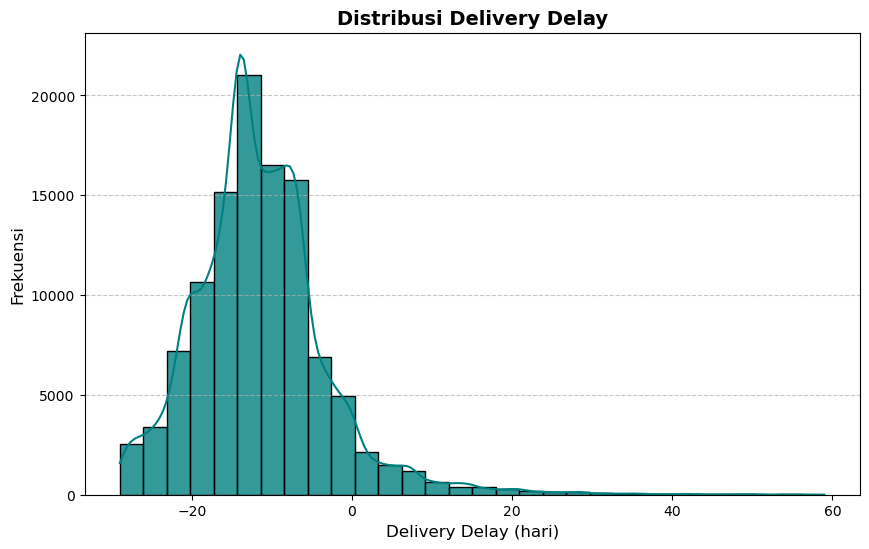

In [ ]:
# Mengatur ukuran grafik agar lebih proporsional
plt.figure(figsize=(10, 6))

# kde=True akan menambahkan garis kurva distribusi di atas histogram
sns.histplot(data=df, x='delivery_delay', bins=30, color='teal', edgecolor='black', kde=True, alpha=0.8)

# Mempercantik tampilan judul dan label sumbu
plt.title('Distribusi Delivery Delay', fontsize=14, fontweight='bold')
plt.xlabel('Delivery Delay (hari)', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)

# Menambahkan garis bantu horizontal (grid)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


Distribusi menunjukkan bahwa sebagian besar pengiriman dilakukan lebih cepat dari estimasi.

Namun, terdapat beberapa kasus keterlambatan ekstrem yang berpotensi memberikan dampak negatif terhadap kepuasan pelanggan.

Hal ini menunjukkan adanya ketidakkonsistenan dalam proses pengiriman.

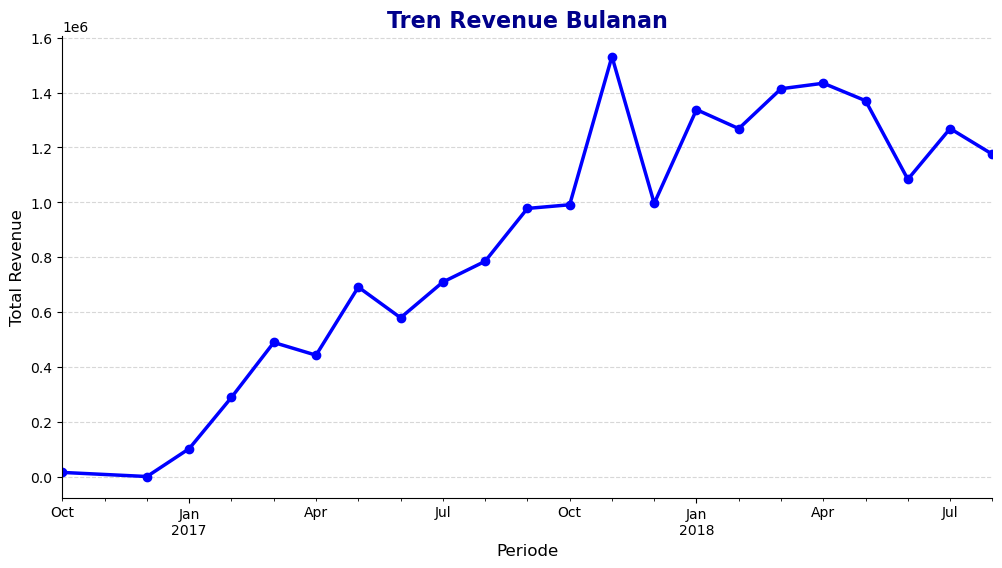

In [104]:
# Mengatur ukuran kanvas agar lebih luas dan proporsional
plt.figure(figsize=(12, 6))

# Membuat line chart dengan warna navy, garis yang tegas, dan penanda titik (marker)
monthly_revenue.plot(
    kind='line', 
    color='Blue', 
    linewidth=2.5, 
    marker='o', 
    markersize=6
)

# Mempercantik tampilan judul dan label dengan warna senada
plt.title('Tren Revenue Bulanan', fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel('Periode', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)

# Menambahkan garis bantu horizontal (grid) yang tipis dan halus
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Menghilangkan garis tepi atas dan kanan agar grafik terlihat lebih bersih (clean)
sns.despine()

plt.show()


Grafik menunjukkan adanya pertumbuhan revenue yang signifikan sepanjang tahun 2017 dan stabil pada tahun 2018.

Terdapat pola fluktuasi yang mengindikasikan adanya faktor musiman dalam perilaku pembelian pelanggan.

Hal ini menunjukkan bahwa bisnis mengalami pertumbuhan yang positif dengan peluang optimalisasi pada periode tertentu.

## **Conclusion & Recommendation**

### Kesimpulan 1: Pengaruh Keterlambatan terhadap Review Score

Berdasarkan analisis pada periode 2017–2018, ditemukan bahwa terdapat hubungan negatif antara keterlambatan pengiriman (delivery_delay) dan review score, dengan nilai korelasi sebesar -0.26.

Hasil analisis menunjukkan bahwa setiap penambahan 1 hari keterlambatan pengiriman menyebabkan penurunan rata-rata review score sekitar 0.042 poin (berdasarkan hasil regresi/slope).

Selain itu, pelanggan dengan review tinggi cenderung menerima pengiriman lebih cepat dibandingkan estimasi.

Namun, karena nilai korelasi tergolong lemah hingga sedang, dapat disimpulkan bahwa keterlambatan pengiriman bukan satu-satunya faktor yang mempengaruhi kepuasan pelanggan.

### Kesimpulan 2: Kategori Produk dengan Revenue Tertinggi Tahun 2018

Berdasarkan analisis pada tahun 2018, diperoleh 10 kategori produk dengan total revenue tertinggi, di antaranya adalah "cama_mesa_banho", "beleza_saude", dan "informatica_acessorios".

Rata-rata review score keseluruhan platform adalah sebesar 4.08.

Hasil perbandingan menunjukkan bahwa tidak semua kategori dengan revenue tinggi memiliki review score di atas rata-rata tersebut. Beberapa kategori seperti "cama_mesa_banho" dan "informatica_acessorios" memiliki nilai review di bawah rata-rata platform.

Hal ini menunjukkan bahwa tingginya kontribusi revenue tidak selalu diikuti oleh tingkat kepuasan pelanggan yang tinggi.

### Rekomendasi

1. **Optimasi Proses Pengiriman**
   - Mengurangi keterlambatan pengiriman dengan meningkatkan efisiensi logistik.
   - Fokus pada kasus keterlambatan ekstrem yang berpotensi menurunkan kepuasan pelanggan secara signifikan.

2. **Perbaikan Kualitas pada Kategori High Revenue**
   - Melakukan evaluasi terhadap kategori produk dengan revenue tinggi namun review rendah.
   - Perbaikan dapat dilakukan pada kualitas produk, deskripsi produk, atau layanan penjual.

3. **Strategi Retensi Pelanggan**
   - Mengembangkan program loyalitas atau promosi ulang untuk meningkatkan repeat order.
   - Hal ini penting karena sebagian besar pelanggan hanya melakukan satu kali transaksi.

4. **Pemanfaatan Kategori dengan Review Tinggi**
   - Meningkatkan promosi pada kategori dengan review tinggi untuk meningkatkan kontribusi revenue.
   - Kategori ini memiliki potensi besar karena sudah memiliki kepuasan pelanggan yang baik.